In [3]:
import numpy as np
from CMGradobject import CMGobject as cmg
import CMfunc as cm
# import ui as ui
import matplotlib.pyplot as plt


computing flow gradients for the following potential flow solutions:
'vortex1: a vortex of strength 0.1 at (x, y) = [0. 0.]'
Done. Generating plots:


Plots generated.


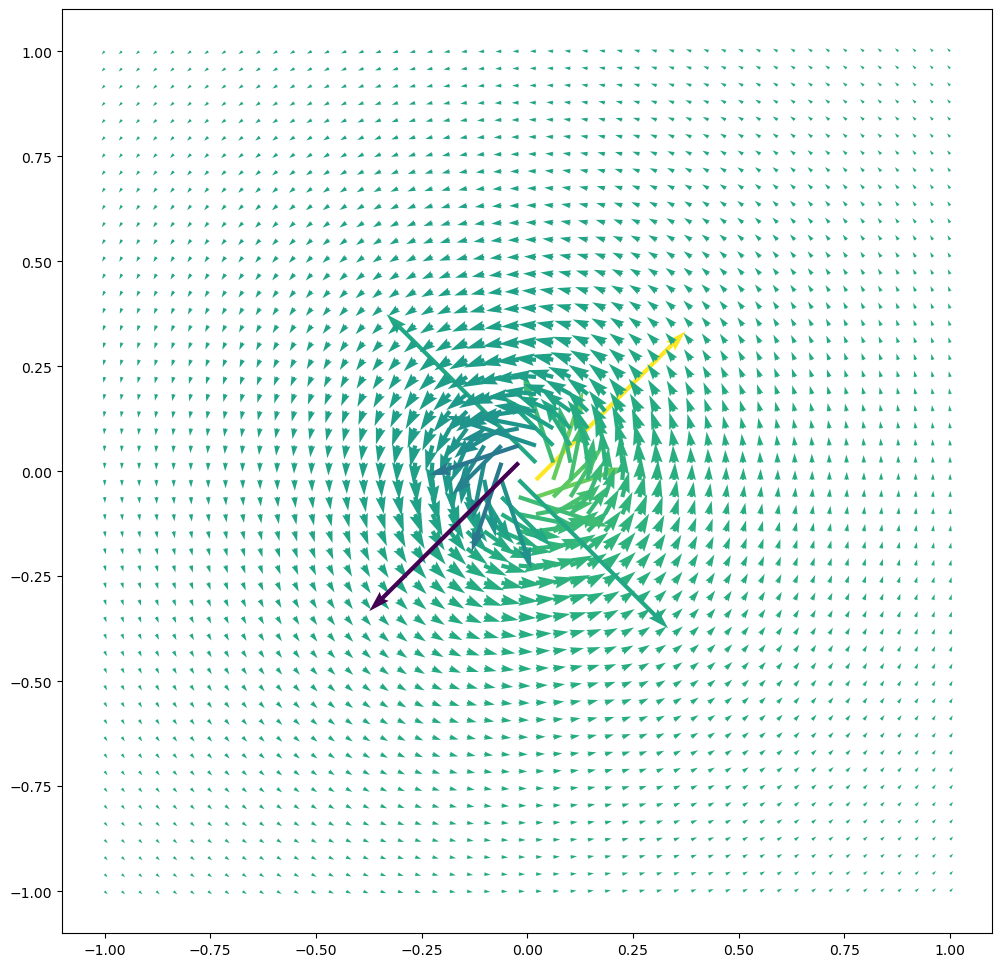

In [5]:
import CMPflow as cmp

incr =  50
# incr =  60
# domain = ui.graphDim()
domain = np.array([-1,1,-1,1])
test_x_cartesian = np.linspace(domain[0], domain[1], incr)
test_y_cartesian = np.linspace(domain[2], domain[3], incr)
xv, yv = np.meshgrid(test_x_cartesian, test_y_cartesian)
test_points_cartesian = np.vstack((xv.flatten(), yv.flatten() )).T

# dict_in = ui.Interface()
fs = {}
# fs['uniform1'] = np.array([ 1.0 ]) # strength
# fs['doublet1'] = np.array([ 1e-3, 0.0, 0.0 ]) # strength, x, y
# fs['sink1'] = np.array([ 1e0, 1.0, 0.0, 0.0 ]) # strength, length*, x, y
# fs['source1'] = np.array([ 1.0, 1.0, 0.0, 0.0 ]) # strength, length*, x, y
# fs['vortex1'] = np.array([ 1e-1, 0.0, 0.0 ]) # strength, x, y
fs['tornado1'] = np.array([ 1.0, 1.0, 0.0, 0.0 ]) # strength, length*, x, y
# fs['whirlpool1'] = np.array([ 1.0, 1.0, 0.0, 0.0 ]) # strength, length*, x, y

flow_list = []

for i, key in enumerate(fs):
    flow_list.append(cmp.identify_flow(key, fs[key]))
    test_points_cartesian = flow_list[i].rule_out_points(test_points_cartesian)
    try:
        check = test_points_cartesian.shape[1]
    except:
        print("Whether or not you meant to, you just asked for a test point that was in a singularity. Give a new test point please")
        x = float(input("enter x coordinate:\n"))
        y = float(input("enter y coordinate:\n"))
        test_points_cartesian = np.array([[x, y]])

print("computing flow gradients for the following potential flow solutions:")
flow = flow_list[0]
print(flow)
flow.compute_points(test_points_cartesian)
F = flow.compute_flow()
for flow in flow_list[1:]:
    print(flow)
    flow.compute_points(test_points_cartesian)
    F += flow.compute_flow()

print("Done. Generating plots:")
cartesian_gradients, potential = cmp.generate_cart_gradients(F, test_points_cartesian)

max_grad = np.max(np.linalg.norm(cartesian_gradients, axis=1))

fig, ax = plt.subplots(1,1, figsize=(12, 12))

plotU = cartesian_gradients.T[0]/max_grad

plotV = cartesian_gradients.T[1]/max_grad

plotN = -1

color = np.sqrt(((plotV-plotN)/2) + ((plotU-plotN)/2))

ax.quiver(test_points_cartesian.T[0], test_points_cartesian.T[1], plotU, plotV, color, angles='xy', scale=2, scale_units='xy', minshaft=1, minlength=1, width=0.01, units='xy')
print("\n\nPlots generated.")
plt.show()
